# Applying Models for Code Generation (OpenAI Codex, GitHub Copilot)

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain how Codex/Copilot-class models generate code (autoregressive LMs trained on source code)
- Train a tiny **character-level model on Python source** and generate code with it
- **Evaluate** the generated code the way code models are evaluated: does it parse? does it run?
- Understand what separates the toy from the real thing (scale, tokenizers, execution-based
  benchmarks like HumanEval)

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 2, lessons 01 and 03 (autoregressive language models, and prompting) — Copilot is that model trained on source code and prompted with your editor buffer.

**Used later in:** Course 12 (AIAT 126) — Unit 3, where these tools are used — and their output verified — during implementation.

---

This notebook covers practical activities from **Course 10, Unit 5**:
- Applying models like OpenAI Codex or GitHub Copilot for code generation

---

## Introduction

**Code generation models** like Codex and Copilot are ordinary autoregressive language models
trained on billions of lines of source code — to them, Python is just text with unusually strict
grammar. We exploit that here: the same char-level LM you used for prose, retrained on Python.

---

## 🌍 Why this lesson exists — two randomised trials, opposite answers

Peng, Kalliamvakou, Cihon & Demirer (2023, arXiv 2302.06590) ran a controlled experiment on developers implementing an HTTP server in JavaScript: the group with GitHub Copilot finished **55.8% faster**. Two years later METR (Becker, Rush, Barnes & Rein, 2025, arXiv 2507.09089) ran 16 experienced open-source developers across **246 real tasks in their own repositories** and measured the opposite — AI tools made them **19% slower**, while those same developers estimated afterwards that they had been **20% faster**.

Both studies are real and neither is wrong. They measured different work: a clean greenfield task versus deep, familiar codebases. Which one your project resembles is the question, and "it feels faster" is not evidence — METR's developers were wrong about their own speed by nearly 40 points.

**What goes wrong without this:** the output of a code model is a *proposal*, and syntactically perfect proposals are the dangerous ones. Pearce et al. (IEEE S&P 2022, arXiv 2108.09293) generated **1,689 programs** from Copilot across **89 security-relevant scenarios** and found approximately **40% were vulnerable** — code that compiles, reads cleanly, and is wrong.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: orientation cell — what Codex and Copilot do, before the
# hands-on next-token generation demo below.
print("✅ Libraries imported!")
print("\nCode Generation Models")
print("=" * 60)

print("\nOpenAI Codex:")
print("  - Code generation")
print("  - Multiple languages")
print("  - Natural language input")
print("  - API access")

print("\nGitHub Copilot:")
print("  - IDE integration")
print("  - Context-aware")
print("  - Real-time suggestions")
print("  - Code completion")

print("\nApplications:")
print("  - Code completion")
print("  - Function generation")
print("  - Bug fixing")
print("  - Documentation")

print("\n✅ Code generation concepts understood!")

✅ Libraries imported!

Code Generation Models

OpenAI Codex:
  - Code generation
  - Multiple languages
  - Natural language input
  - API access

GitHub Copilot:
  - IDE integration
  - Context-aware
  - Real-time suggestions
  - Code completion

Applications:
  - Code completion
  - Function generation
  - Bug fixing
  - Documentation

✅ Code generation concepts understood!


### The Two Trials, Side by Side

The header of this notebook names two randomised experiments that measured the same thing —
developer speed with an AI coding assistant — and got answers with opposite signs. The bar chart
plots them next to the developers' own estimate of what happened to them.

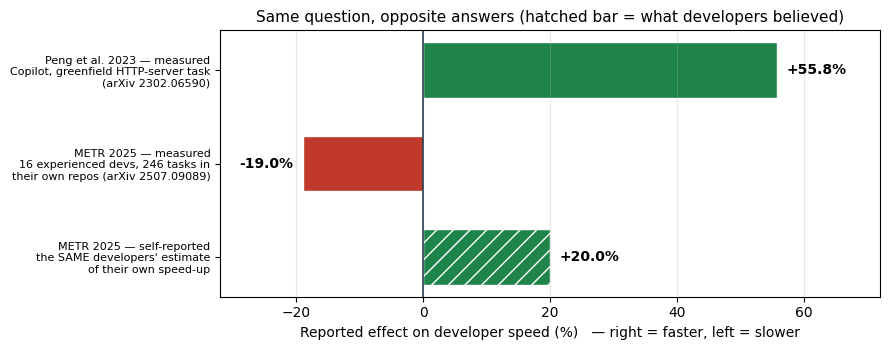

METR's developers estimated +20% while being measured at -19%
-> self-assessment was off by 39 percentage points, in the wrong direction.


In [2]:
# Plot the three numbers the opening section cites. WHY: "two trials, opposite answers"
# is the claim this lesson rests on, and a signed bar chart shows a sign flip instantly.
# These are REPORTED results from the two published papers, not measured in this notebook.
import numpy as np
import matplotlib.pyplot as plt

studies = [   # (label, reported effect on developer speed in %, is it measured or self-reported)
    ("Peng et al. 2023 — measured\nCopilot, greenfield HTTP-server task\n(arXiv 2302.06590)", +55.8, True),
    ("METR 2025 — measured\n16 experienced devs, 246 tasks in\ntheir own repos (arXiv 2507.09089)", -19.0, True),
    ("METR 2025 — self-reported\nthe SAME developers' estimate\nof their own speed-up", +20.0, False),
]
labels = [s[0] for s in studies]
values = [s[1] for s in studies]
measured = [s[2] for s in studies]

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(studies))[::-1]                       # first study at the top
bars = ax.barh(y, values, height=0.6,
               color=["#1e8449" if v > 0 else "#c0392b" for v in values],
               hatch=[None if m else "//" for m in measured], edgecolor="white")
for yi, v in zip(y, values):
    ax.text(v + (1.5 if v > 0 else -1.5), yi, f"{v:+.1f}%", va="center",
            ha="left" if v > 0 else "right", fontsize=10, fontweight="bold")
ax.axvline(0, color="#2c3e50", lw=1.2)                  # no effect
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Reported effect on developer speed (%)   — right = faster, left = slower")
ax.set_xlim(-32, 72)
ax.set_title("Same question, opposite answers (hatched bar = what developers believed)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

gap = studies[2][1] - studies[1][1]
print(f"METR's developers estimated {studies[2][1]:+.0f}% while being measured at {studies[1][1]:+.0f}%")
print(f"-> self-assessment was off by {gap:.0f} percentage points, in the wrong direction.")


**Read the figure.** Two randomised experiments, one question, opposite signs. The green bar is
Peng et al. on a clean greenfield task; the red bar is METR on real work in repositories the
developers already knew. Neither study is wrong — they measured different work, and which bar
your project resembles is the question worth arguing about.

The hatched bar is the one to keep. It is the **same METR developers' estimate of their own
speed-up** while they were being measured at −19%: a **39-point** error, in the wrong direction.
That is the evidentiary standard this notebook is asking for — "it feels faster" is not data, and
that includes when it is your own feeling.

## 🌍 Worked Example — a Character-Level Model Trained on Python

**Industry context:**
- GitHub Copilot autocompletes code token by token from your file's context
- Codex (the model behind early Copilot) was GPT-3 fine-tuned on public code
- Modern coding models are evaluated by *executing* their output (HumanEval, MBPP benchmarks)

We train the course's character-level LM on a tiny corpus of **Python functions** and then ask it
to complete `def add(a, b):` — real code generation, at one-millionth the scale. Afterwards we
evaluate the output the honest way: by checking whether Python can actually parse it.

In [3]:
# Train a tiny character-level LM on Python source code, generate a completion, and
# evaluate it with a parse check. WHY: this is Copilot's recipe in miniature — and the
# evaluation shows exactly why code models need scale.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training corpus: real (tiny) Python functions, repeated for more windows ─
snippet = (
    "def add(a, b):\n    return a + b\n\n"
    "def sub(a, b):\n    return a - b\n\n"
    "def mul(a, b):\n    return a * b\n\n"
    "def square(a):\n    return a * a\n\n"
    "def half(a):\n    return a / 2\n\n"
)
text = snippet * 3

# ── Tokenize: every distinct character is a token (newlines and colons too) ─
chars  = sorted(set(text))
c2i    = {c: i for i, c in enumerate(chars)}
i2c    = {i: c for c, i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]
print(f"Vocabulary: {VOCAB} characters (letters, digits, newline, ':', '+', ...)")

# ── Training windows: 20 characters in -> next character out ──────────────
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc) - SEQ_LEN - 1):
    X_list.append(enc[i:i + SEQ_LEN])
    y_list.append(enc[i + SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── Same LSTM language model as Unit 2 — only the corpus changed ──────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])              # logits for the next character

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# ── Train with mini-batches for 200 steps ─────────────────────────────────
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Generate: complete a function header, sampling with temperature ───────
def generate(seed_str, steps=80, temperature=0.5):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

np.random.seed(0)
completion = generate("def add(a, b):\n", steps=60, temperature=0.5)
print("\n── Generated Python ────────────────────────────────────────────")
print(completion)

# ── Evaluate like a code model: can Python parse it? (computed, not assumed) ─
# We cut at the last blank line so we judge only complete function blocks.
candidate = completion.rsplit("\n\n", 1)[0]
import ast
try:
    ast.parse(candidate)
    print("\n✅ ast.parse: the generated snippet IS syntactically valid Python.")
except SyntaxError as e:
    print(f"\n❌ ast.parse: SyntaxError ({e.msg}, line {e.lineno}) — the model produced")
    print("   code-LOOKING text that Python rejects.")

# ── Evaluate SEMANTICS: execute it and run a unit test (HumanEval in miniature) ─
# Syntax can pass while the logic is wrong — only a test can tell the difference.
ns = {}
try:
    exec(candidate, ns)                                  # run the generated code
    if 'add' in ns:
        result = ns['add'](2, 3)
        verdict = "✅ PASSED" if result == 5 else "❌ FAILED"
        print(f"\nUnit test add(2, 3) == 5 → got {result} → {verdict}")
    else:
        print("\nUnit test skipped: the snippet did not define add().")
except Exception as e:
    print(f"\nExecution error: {type(e).__name__}: {e}")

print("\nThe lesson: correctness must be CHECKED, never assumed — real code models are")
print("graded by executing outputs against tests (HumanEval), and even Copilot-class")
print("systems make errors, which is why their suggestions always need review.")

Vocabulary: 25 characters (letters, digits, newline, ':', '+', ...)


Epoch 0 — loss: 3.234


Epoch 50 — loss: 0.471


Epoch 100 — loss: 0.069


Epoch 150 — loss: 0.035



── Generated Python ────────────────────────────────────────────
def add(a, b):
    return a - b

def mul(a, b):
    return a * b

def squar

✅ ast.parse: the generated snippet IS syntactically valid Python.

Unit test add(2, 3) == 5 → got -1 → ❌ FAILED

The lesson: correctness must be CHECKED, never assumed — real code models are
graded by executing outputs against tests (HumanEval), and even Copilot-class
systems make errors, which is why their suggestions always need review.


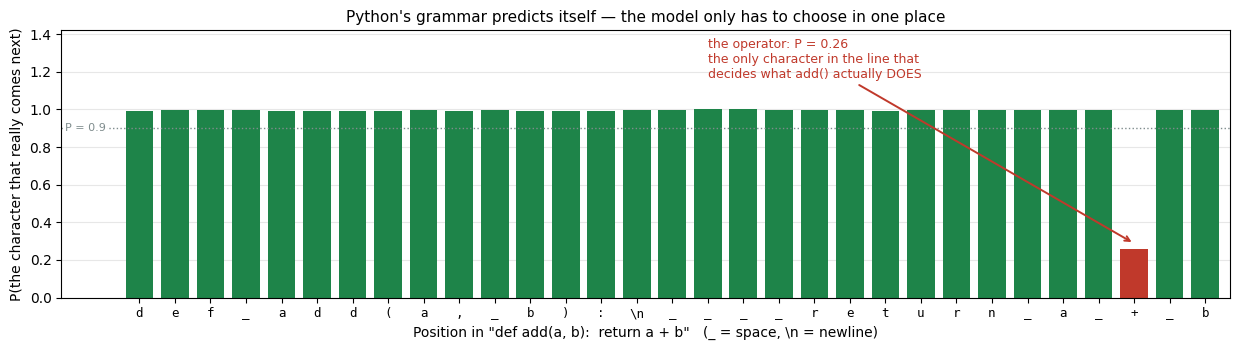

Characters the model is >90% sure of : 30/31 (97%)
Median probability over the whole line: 0.99
Hardest character                     : '+' at position 28, P = 0.26
Positions below P = 0.90               : 1 of 31 -> ['+']
Lowest probability among ALL the others: 0.99


In [4]:
# WHY did it write "a - b"? Ask the model, character by character. For every position
# in one line of the corpus we re-run it on the 20 characters before that position and
# read off the probability it gave the character that ACTUALLY comes next. No sampling
# here — these are the model's own beliefs, so the figure is deterministic.
import numpy as np
import matplotlib.pyplot as plt

TARGET = "def add(a, b):\n    return a + b"
start  = len(snippet)                      # the SECOND copy, so 20 chars of context exist
assert text[start:start + len(TARGET)] == TARGET

probs_true, shown = [], []
model.eval()
for j in range(start, start + len(TARGET)):
    ctx = torch.tensor([enc[j - SEQ_LEN:j]], dtype=torch.long)
    with torch.no_grad():
        p = torch.softmax(model(ctx)[0], dim=0).numpy()
    probs_true.append(float(p[enc[j]]))
    ch = text[j]
    shown.append({"\n": "\\n", " ": "_"}.get(ch, ch))   # make whitespace visible on the axis
probs_true = np.array(probs_true)

# green = the model already knows this character, red = it is genuinely choosing
colours = ["#1e8449" if q > 0.9 else "#e67e22" if q > 0.5 else "#c0392b" for q in probs_true]

fig, ax = plt.subplots(figsize=(12.5, 3.6))
ax.bar(range(len(shown)), probs_true, color=colours, width=0.78)
ax.set_xticks(range(len(shown)))
ax.set_xticklabels(shown, fontsize=9, family="monospace")
ax.set_ylim(0, 1.42); ax.set_xlim(-2.2, len(shown) - 0.3)
ax.set_ylabel("P(the character that really comes next)")
ax.set_xlabel('Position in "def add(a, b):  return a + b"   (_ = space, \\n = newline)')
ax.axhline(0.9, ls=":", color="#7f8c8d", lw=1)
ax.text(-2.1, 0.9, "P = 0.9", fontsize=8, color="#7f8c8d", va="center",   # left of the bars
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"))     # so the dotted line does not cross it

worst = int(np.argmin(probs_true))          # the single hardest character in the line
# the annotation goes ABOVE the bars, or it is unreadable on top of them
ax.annotate(f"the operator: P = {probs_true[worst]:.2f}\nthe only character in the line that\ndecides what add() actually DOES",
            xy=(worst, probs_true[worst] + 0.03), xytext=(worst - 12, 1.38), fontsize=9,
            color="#c0392b", va="top", ha="left",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.4))
ax.set_title("Python's grammar predicts itself — the model only has to choose in one place",
             fontsize=11)
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── The same evidence, printed ────────────────────────────────────────────
easy = int((probs_true > 0.9).sum())
print(f"Characters the model is >90% sure of : {easy}/{len(shown)} "
      f"({100 * easy / len(shown):.0f}%)")
print(f"Median probability over the whole line: {np.median(probs_true):.2f}")
print(f"Hardest character                     : {shown[worst]!r} at position {worst}, P = {probs_true[worst]:.2f}")
below = np.where(probs_true < 0.9)[0]
print(f"Positions below P = 0.90               : {len(below)} of {len(shown)} "
      f"-> {[shown[int(j)] for j in below]}")
print(f"Lowest probability among ALL the others: {probs_true[probs_true >= 0.9].min():.2f}")

**Read the figure.** One bar per character of `def add(a, b): return a + b`, each showing how much
probability the model put on the character that really came next — its own belief, not a sample.

Almost every bar is green and at the ceiling. The model is essentially certain about `e` after `d`,
about the colon after `)`, about the four spaces of indentation, about every letter of `return`.
That is not intelligence, it is **grammar**: Python's syntax leaves almost no choice at almost every
position, and a model that has seen a few function definitions can replay it.

Then look at the red bar the arrow points to. At the operator the probability collapses — the
twenty characters of context before it are `a, b):` + newline + `    return a `, and that window is
character-for-character identical in `add`, `sub` and `mul` — three functions whose operators are
`+`, `-` and `*`. Nothing the model can see says which one this is, so it splits its belief between
them and puts only **0.26** on the right answer. That single position is the only one in the line where the model is genuinely choosing, and it
is the only one that decides what the function *does*.

This is the cause of the failure printed above: the completion that parsed cleanly returned
`a - b`. The model got every character it was certain about right, and the one character that
mattered wrong. Generalise it and you have Pearce et al.'s finding — code that compiles, reads
cleanly, and is wrong.

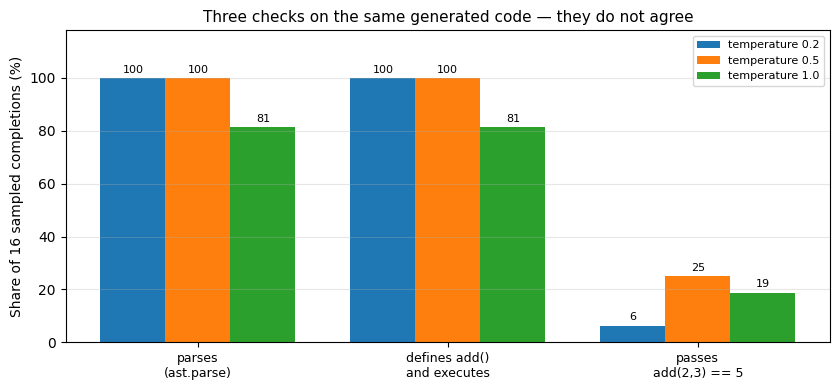

16 completions of 'def add(a, b):' at each temperature

 temp |   parses |     runs |  correct | gap parses->correct
  0.2 |     100% |     100% |       6% |     94 points
  0.5 |     100% |     100% |      25% |     75 points
  1.0 |      81% |      81% |      19% |     62 points


In [5]:
# One sample proved nothing. Sample MANY completions and measure the three checks
# separately. WHY: "it parses" and "it is correct" are different questions, and the
# distance between them is the whole lesson — so measure it instead of asserting it.
import ast
import numpy as np
import matplotlib.pyplot as plt

TEMPS = [0.2, 0.5, 1.0]                      # low temperature = safe/repetitive, high = adventurous
N = 16                                       # completions per temperature (keeps the run cheap)
CHECKS = ["parses\n(ast.parse)", "defines add()\nand executes", "passes\nadd(2,3) == 5"]
rates = {}

np.random.seed(7)
for temp in TEMPS:
    n_parse = n_runs = n_correct = 0
    for _ in range(N):
        candidate = generate("def add(a, b):\n", steps=60, temperature=temp).rsplit("\n\n", 1)[0]
        try:
            ast.parse(candidate)             # check 1: is it syntactically Python?
        except SyntaxError:
            continue
        n_parse += 1
        ns = {}
        try:
            exec(candidate, ns)              # check 2: does it run and define the function?
        except Exception:
            continue
        if "add" not in ns:
            continue
        n_runs += 1
        try:
            if ns["add"](2, 3) == 5:         # check 3: is it RIGHT?
                n_correct += 1
        except Exception:
            pass
    rates[temp] = [100 * n_parse / N, 100 * n_runs / N, 100 * n_correct / N]

# ── Plot the three checks side by side, per temperature ───────────────────
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(CHECKS)); w = 0.26
for k, temp in enumerate(TEMPS):
    bars = ax.bar(x + (k - 1) * w, rates[temp], w, label=f"temperature {temp}")
    for b, v in zip(bars, rates[temp]):
        ax.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CHECKS, fontsize=9)
ax.set_ylabel(f"Share of {N} sampled completions (%)"); ax.set_ylim(0, 118)
ax.set_title("Three checks on the same generated code — they do not agree", fontsize=11)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── The same measurement, printed ─────────────────────────────────────────
print(f"{N} completions of 'def add(a, b):' at each temperature\n")
print(f"{'temp':>5} | {'parses':>8} | {'runs':>8} | {'correct':>8} | gap parses->correct")
for temp in TEMPS:
    p, r, c = rates[temp]
    print(f"{temp:>5} | {p:7.0f}% | {r:7.0f}% | {c:7.0f}% | {p - c:6.0f} points")


**Read the figure.** Sixteen completions of the same prompt at each of three temperatures, put
through the three checks in order.

At temperature 0.2 **every** completion parses and **every** completion runs and defines `add()` —
and **6%** of them return 5 for `add(2, 3)`. That is a **94-point gap** between the check that is
trivial to run and the check that matters. At 0.5 the gap is 75 points; at 1.0 the model starts
emitting text Python rejects (81% parse) and correctness still sits at 19%.

Two things to take from the shape of it. First, the left two groups are the same height:
*executing* the code adds almost nothing over *parsing* it, because these snippets are valid
function definitions either way — running code is not the same as testing it. Second, no
temperature closes the gap. Turning the sampler down produced output that was more confidently
wrong, not more correct.

*(Honest limit: 16 samples per temperature makes each bar coarse — one completion is 6 points. The
size of the parse-to-correct gap is the robust finding here; the ordering between temperatures is
not.)*

This is HumanEval's design in miniature, and the reason it exists: grade a code model by
**running its output against a test**, because every cheaper check it will pass.

## 💬 Discuss

1. Our snippet passed `ast.parse` and then failed `add(2, 3) == 5` by returning **-1**. Which of those two checks does a hurried developer actually run? What does your answer predict about bug rates in Copilot-assisted codebases?
2. Peng et al. measured **+55.8%** on a greenfield task; METR measured **−19%** on real repositories, with developers believing the opposite. What differs between the two settings — and which one resembles your graduation project?
3. Pearce et al. found ~40% of security-relevant completions vulnerable. Write the policy you would hand to a team of five junior developers using an AI assistant on a payment system. Keep it to five rules.


## ⚠️ Where this breaks

**Parse-checking is the weakest possible test.** `ast.parse` accepts every syntactically valid program, including the wrong one — which is exactly what our model produced. Syntactic validity is necessary and tells you almost nothing.

**Character-level generation cannot represent identifiers, scope or types.** The useful minimum for a code model is subword tokenization plus repository context, which is why production systems are orders of magnitude larger and are paired with retrieval over your codebase.

**Self-reported productivity is not productivity.** METR's participants were wrong about their own speed in the wrong direction. Do not accept "it feels faster" as evidence — from a vendor, from a teammate, or from yourself. Measure task completion time on tasks you did not choose after the fact.

**The evaluation that counts is execution-based.** HumanEval, MBPP and SWE-bench grade code models by *running* the output against tests. Do the same locally: never accept generated code because it looks right, and write the test before you read the suggestion, not after.


## 📚 References & Further Reading

**Papers:**
- Chen et al. (2021) — [Evaluating Large Language Models Trained on Code](https://arxiv.org/abs/2107.03374) *(the Codex paper; introduced HumanEval)*
- Radford et al. (2019) — [GPT-2](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

**Interactive:**
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) — build GPT in 300 lines
- [GitHub Copilot documentation](https://docs.github.com/en/copilot)

**State-of-the-Art:** modern coding assistants pair code-trained LLMs with retrieval over your
repository and execution feedback; benchmarks (HumanEval, SWE-bench) grade them by running tests.

## 📝 Summary

In this notebook, you:

- Saw that Codex/Copilot-class systems are **autoregressive language models trained on source
  code** — the same mechanism as Unit 2's text models
- **Trained a char-level LM on Python functions** and generated a completion for `def add(a, b):`
- **Evaluated** the output with a parse check (`ast.parse`) — the small-scale version of the
  execution-based benchmarks (HumanEval) used on real code models
- Learned what separates the toy from production: massive code corpora, subword tokenizers,
  repository context, and test-based evaluation

**Key takeaway:** generated code is a *proposal* — always validated by parsing, tests, and review.